In [26]:
import warnings
warnings.filterwarnings("ignore")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [29]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="datetime.datetime.utcnow() is deprecated"
)

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/DWDM_Project/data/processed/samsung_processed_dataset.csv")

df.head()

,Product,Category,Rating,Review,Platform,Date,Issue,RSI,Sentiment_score
0,Samsung Buds Live,Accessories,5,worth it house save decide although bag fight ...,Flipkart,2024-12-14,none,0.0600,0.5859
1,Samsung Galaxy M14,Smartphone,2,waste of money issue display flickering,Flipkart,2022-07-04,display,0.6536,-0.4215
2,Samsung Galaxy M53,Smartphone,5,excellent game threat see head cover task see,Flipkart,2022-07-21,none,0.0600,0.0772
3,Samsung Galaxy Tab A8,Smartphone,4,good,Amazon,2024-03-13,none,0.1350,0.4404
4,Samsung Charger 25W,Accessories,1,average join hotel daughter water,Flipkart,2024-11-13,heating,0.5600,0.2960


PART A — CLASSIFICATION

In [ ]:
df["High_Risk"] = (df["RSI"] > 0.5).astype(int)

In [ ]:
from sklearn.model_selection import train_test_split

X = df[["Rating", "Sentiment_score"]]
y = df["High_Risk"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93      1012
           1       0.88      0.84      0.86       487

    accuracy                           0.91      1499
   macro avg       0.90      0.89      0.90      1499
weighted avg       0.91      0.91      0.91      1499



PART B — CLUSTERING

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(df[["RSI"]])

In [ ]:
df.groupby("Cluster")["RSI"].mean()

,RSI
Cluster,
0,0.624135
1,0.143920
2,0.437727


 PART C — ASSOCIATION RULE MINING

In [ ]:
df_apriori = df[["Issue", "High_Risk"]]

df_encoded = pd.get_dummies(df_apriori)

In [27]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_items = apriori(df_encoded, min_support=0.05, use_colnames=True)

rules = association_rules(frequent_items, metric="confidence", min_threshold=0.6)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Issue_general_issue),(High_Risk),0.193088,0.330531,0.161463,0.836213,2.529907,1.0,0.097641,4.087433,0.749435,0.445836,0.755348,0.662354


PART D — OUTLIER DETECTION

In [28]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42)

df["Outlier"] = iso.fit_predict(df[["RSI"]])

In [30]:
df[df["Outlier"] == -1].head()

,Product,Category,Rating,Review,Platform,Date,Issue,RSI,Sentiment_score,High_Risk,Cluster,Outlier,Risk_Probability,Month,Cluster_Label
20,Samsung Galaxy A54,Smartphone,1,bad less relationship cultural store either,Flipkart,2022-06-26,general_issue,0.77692,-0.5423,1,0,-1,0.999975,2022-06,High Risk
22,Samsung Galaxy A54,Smartphone,1,bad ever next always article news issue batter...,Flipkart,2023-09-28,battery,0.77692,-0.5423,1,0,-1,0.999975,2023-09,High Risk
80,Samsung Galaxy M53,Smartphone,1,waste of money college carry rise personal tes...,Flipkart,2023-11-08,general_issue,0.72860,-0.4215,1,0,-1,0.999919,2023-11,High Risk
114,Samsung Galaxy Tab A8,Smartphone,1,waste of money issue charging problem,Amazon,2024-10-06,battery,0.82820,-0.6705,1,0,-1,0.999993,2024-10,High Risk
135,Samsung Galaxy A34,Smartphone,2,waste of money issue charging problem,Flipkart,2023-11-22,battery,0.75320,-0.6705,1,0,-1,0.999838,2023-11,High Risk


In [31]:
import joblib

joblib.dump(model, "/content/drive/MyDrive/DWDM_Project/outputs/models/logistic_model.pkl")
joblib.dump(kmeans, "/content/drive/MyDrive/DWDM_Project/outputs/models/kmeans_model.pkl")

['/content/drive/MyDrive/DWDM_Project/outputs/models/kmeans_model.pkl']

In [32]:
print(df["High_Risk"].value_counts())

High_Risk
0    5017
1    2477
Name: count, dtype: int64


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[954  58]
 [ 78 409]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      1012
           1       0.88      0.84      0.86       487

    accuracy                           0.91      1499
   macro avg       0.90      0.89      0.90      1499
weighted avg       0.91      0.91      0.91      1499



In [34]:
# Feature Importance
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Weight": model.coef_[0]
})

print("Feature Importance:")
print(importance)

Feature Importance:
           Feature    Weight
0           Rating -3.151354
1  Sentiment_score -9.878703


In [35]:
df["Risk_Probability"] = model.predict_proba(X)[:,1]

df[["Rating", "Sentiment_score", "Risk_Probability"]].head()

,Rating,Sentiment_score,Risk_Probability
0,5,0.5859,0.000002
1,2,-0.4215,0.998109
2,5,0.0772,0.000300
3,4,0.4404,0.000194
4,1,0.2960,0.911499


In [36]:
product_risk = df.groupby("Product")["RSI"].mean().sort_values(ascending=False)

print("Top Risky Products:")
print(product_risk.head(10))

Top Risky Products:
Product
 Samsung Washing Machine     0.412093
Samsung Air Conditioner      0.411969
 Samsung Galaxy Buds2        0.390473
 Samsung Buds 2              0.384668
 Samsung Crystal UHD TV      0.383968
Samsung Soundbar             0.381304
Samsung Galaxy Buds2         0.379174
 Samsung Galaxy S22          0.376562
Samsung Buds Live            0.374216
 Samsung Galaxy Watch6       0.373030
Name: RSI, dtype: float64


In [37]:
platform_analysis = df.groupby("Platform")["RSI"].mean()

print("Platform Comparison:")
print(platform_analysis)

Platform Comparison:
Platform
Amazon      0.35612
Flipkart    0.35134
Name: RSI, dtype: float64


In [38]:
df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.to_period("M")

monthly_trend = df.groupby("Month")["RSI"].mean()

print(monthly_trend.head())

Month
2022-01    0.360792
2022-02    0.359972
2022-03    0.345731
2022-04    0.354174
2022-05    0.347348
Freq: M, Name: RSI, dtype: float64


In [39]:
cluster_summary = df.groupby("Cluster")["RSI"].mean()

cluster_map = {
    cluster_summary.idxmin(): "Low Risk",
    cluster_summary.idxmax(): "High Risk"
}

df["Cluster_Label"] = df["Cluster"].map(cluster_map).fillna("Medium Risk")

print(df[["RSI", "Cluster_Label"]].head())

      RSI Cluster_Label
0  0.0600      Low Risk
1  0.6536     High Risk
2  0.0600      Low Risk
3  0.1350      Low Risk
4  0.5600     High Risk


In [40]:
rules = rules.sort_values(by="lift", ascending=False)

rules = rules[rules["confidence"] > 0.6]

print(rules[["antecedents", "consequents", "support", "confidence", "lift"]].head())

             antecedents  consequents   support  confidence      lift
0  (Issue_general_issue)  (High_Risk)  0.161463    0.836213  2.529907


In [41]:
print(product_risk.head(5))

Product
 Samsung Washing Machine     0.412093
Samsung Air Conditioner      0.411969
 Samsung Galaxy Buds2        0.390473
 Samsung Buds 2              0.384668
 Samsung Crystal UHD TV      0.383968
Name: RSI, dtype: float64


In [42]:
df["Product"] = df["Product"].str.strip().str.lower()

In [43]:
product_risk = df.groupby("Product")["RSI"].mean().sort_values(ascending=False)

print(product_risk.head(10))

Product
samsung air conditioner    0.393665
samsung washing machine    0.386860
samsung galaxy buds2       0.383411
samsung buds live          0.368533
samsung soundbar           0.368090
samsung galaxy book 2      0.364048
samsung buds 2             0.363751
samsung galaxy tab a8      0.363466
samsung galaxy m14         0.361723
samsung galaxy a14         0.361290
Name: RSI, dtype: float64


In [44]:
print("\n========== FINAL INSIGHTS ==========\n")

# Top risky products
print("Top Risky Products:")
print(product_risk.head(5))

# Most impactful issues
print("\nTop Issues Causing Regret:")
print(df.groupby("Issue")["RSI"].mean().sort_values(ascending=False).head(5))

# Platform comparison
print("\nPlatform Risk Comparison:")
print(df.groupby("Platform")["RSI"].mean())

# High risk percentage
high_risk_percent = df["High_Risk"].mean() * 100
print(f"\nHigh Risk Reviews: {high_risk_percent:.2f}%")

# Cluster distribution
print("\nCluster Distribution:")
print(df["Cluster_Label"].value_counts())


========== FINAL INSIGHTS ==========

Top Risky Products:
Product
samsung air conditioner    0.393665
samsung washing machine    0.386860
samsung galaxy buds2       0.383411
samsung buds live          0.368533
samsung soundbar           0.368090
Name: RSI, dtype: float64

Top Issues Causing Regret:
Issue
camera           0.573297
general_issue    0.564005
battery          0.556448
display          0.539475
performance      0.525125
Name: RSI, dtype: float64

Platform Risk Comparison:
Platform
Amazon      0.35612
Flipkart    0.35134
Name: RSI, dtype: float64

High Risk Reviews: 33.05%

Cluster Distribution:
Cluster_Label
Low Risk       3537
High Risk      2199
Medium Risk    1758
Name: count, dtype: int64


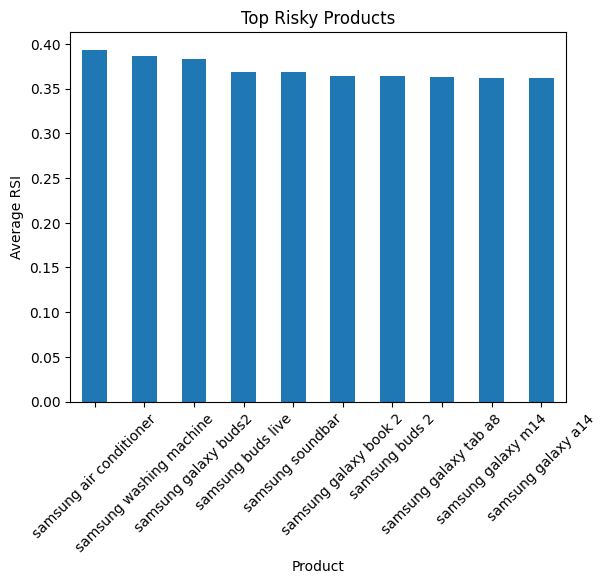

In [45]:
import matplotlib.pyplot as plt

product_risk.head(10).plot(kind="bar")
plt.title("Top Risky Products")
plt.xlabel("Product")
plt.ylabel("Average RSI")
plt.xticks(rotation=45)
plt.show()

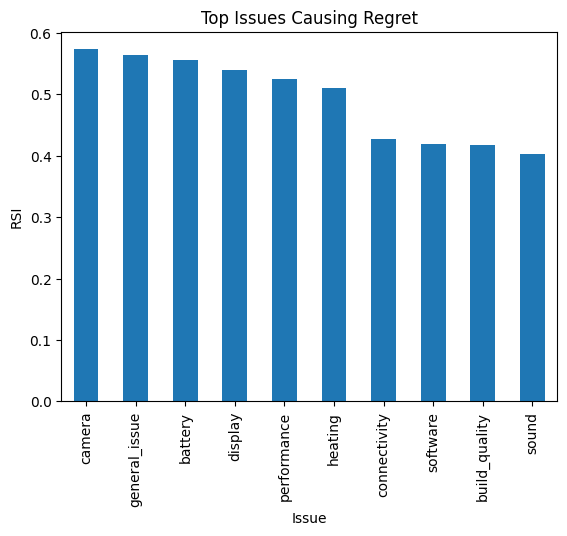

In [46]:
df.groupby("Issue")["RSI"].mean().sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top Issues Causing Regret")
plt.ylabel("RSI")
plt.show()

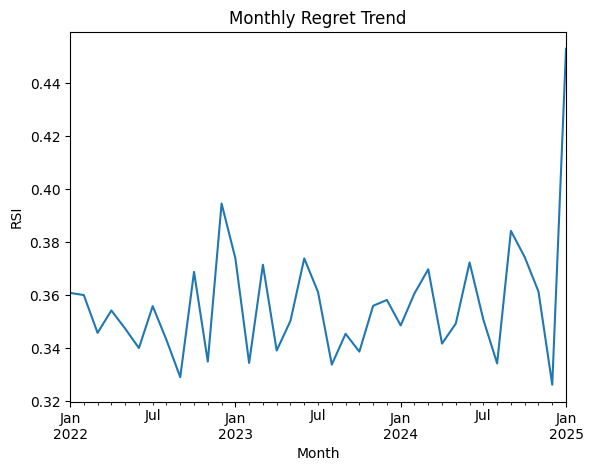

In [47]:
monthly_trend.plot()

plt.title("Monthly Regret Trend")
plt.ylabel("RSI")
plt.show()